Comparing performance of ML approaches for activity classification.... in other words, mutli-class classification model with different algorithms comparing the performance w/ each algorithm.

-> Makes sense, 11:51 min video w/ 100 samples per sec... so hence we expect approx. 71100 samples/lines of data & note that we are not required to use VOTT or any other annotation/tagging tool
   as we are already provided with the ```a3_activity_annotations.csv``` which has already done this.

-> Classes: Walking, Standing, Jogging, Side-step (4 ttl classes)

-> ```imu data columns: timestamp, x-axis acceleration, y-axis acceleration, z-axis acceleration, x-axis gyro, y-axis gyro, z-axis gyro``` (acceleration and gyroscope values are reported in arbitrary units (16-bit signed values) which represent a range of +/- 8g for the accelerometer and +/- 8000dps (degrees-per-second) for the gyroscope.)

### Steps:
  - Align and combine a dataset captured from an inertial sensor with an activity annotation file produced from a video recording of the data capture session.
  - Visualize the combined dataset to check that the data has been correctly imported into Python and aligned with activity transitions.
  - Process the activity annotation data to assign a target activity to each data point within the IMU dataset.
  - Calculate a set of features from the raw sensor data.
  - Apply a machine learning workflow to test a selection of classification algorithms on the feature set for the task of activity classification.
  - Perform hyper-parameter optimization on at least one parameter for each algorithm.
  - Create some visualizations and report on the model that your machine learning approaches have learned from the data.


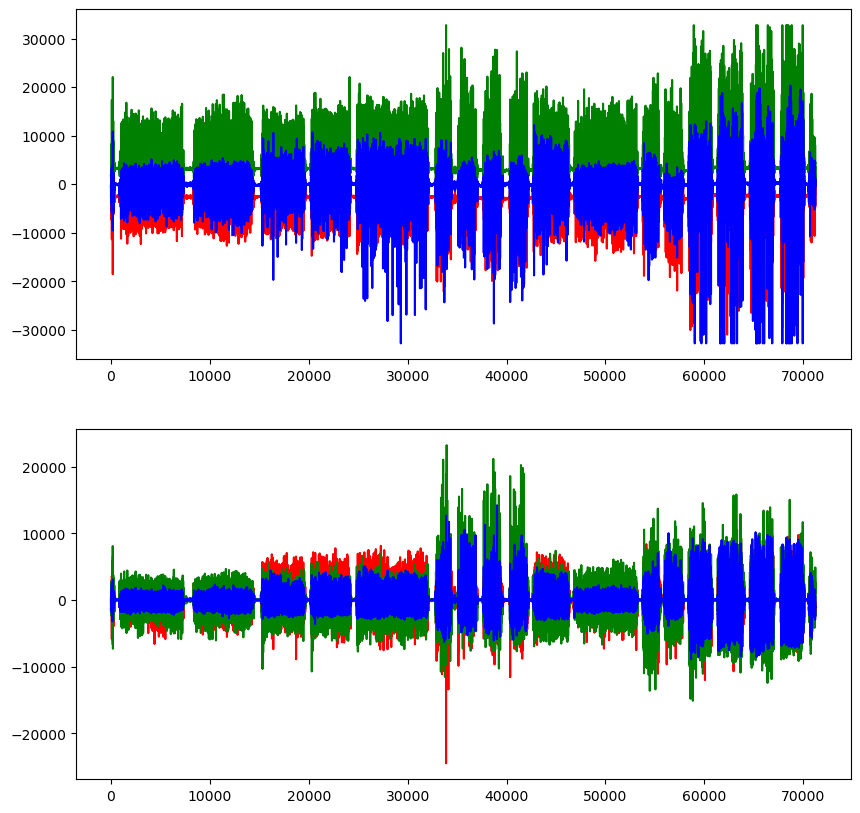

In [ ]:
import csv
import matplotlib.pyplot as plt

# lists to store IMU data:

# epoch timestamps for each reading
time_track = []

# Accelerometer data:
x_axis_acceleration_data = []
y_axis_acceleration_data = []
z_axis_acceleration_data = []

# Gyrometer data:
x_axis_gyro = []
y_axis_gyro = []
z_axis_gyro = []

activity_label = []

def map_activity(activity_string):
    if activity_string == 'Standing':
        return 0
    elif activity_string == 'Walking':
        return 1
    elif activity_string == 'Side-Step':
        return 2
    elif activity_string == 'Running':
        return 3
    elif activity_string == 'Jogging':
        return 4
    
with open('a3_imu_data.csv',newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        time_track.append(float(row[0]))
        x_axis_acceleration_data.append(float(row[1]))
        y_axis_acceleration_data.append(float(row[2]))
        z_axis_acceleration_data.append(float(row[3]))
        x_axis_gyro.append(float(row[4]))
        y_axis_gyro.append(float(row[5]))
        z_axis_gyro.append(float(row[6]))
        
fig,ax = plt.subplots(2,1,figsize=(10,10))
ax[0].plot(x_axis_acceleration_data, color='r')
ax[0].plot(y_axis_acceleration_data, color='g')
ax[0].plot(z_axis_acceleration_data, color='b')

ax[1].plot(x_axis_gyro, color='r')
ax[1].plot(y_axis_gyro, color='g')
ax[1].plot(z_axis_gyro, color='b')

In [ ]:
print(len(time_track)) #check if match 71.1k estimate....
print(time_track[:20]) # just to see whats up here...
print(time_track[0]) #first timestamp
print(time_track[-1]) #last timestamp
print(time_track[-1] - time_track[0]) #total duration in secs, compare to 711

71242
[1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0, 1598240213.0]
1598240213.0
1598240943.0
730.0


Ok so we have 71,242 so a bit of excess data we need to chop off...
and 730 is more than 711... so we have like 19sec of data we need to chop off i.e. where the data from the IMU was being logged, but the video was not recording.... also note that 71242/730.0 = 97.59 (so on avg 97.59 samples per sec... not exactly 100)

So somewhere within the dataset file, there is approx 19 sec worth of rows (~1900 since 100 samples per sec) that fall outside vid, either before start, after end or split between the two... we now need to find when...

Well we know vid starts w/ walking & ends with like a running then finally standing at the very end.... 

So now Looking @ the very beginning & end visually:

Text(0.5, 1.0, 'Last 3000 samples ~ 30 sec')

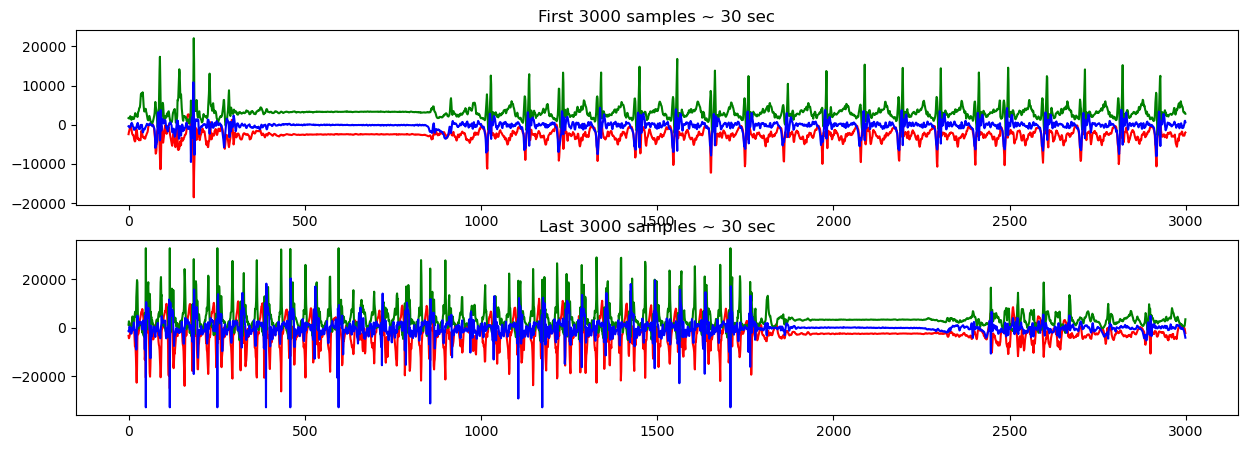

In [7]:
fig,ax = plt.subplots(2, 1, figsize=(15,5))

ax[0].plot(x_axis_acceleration_data[0:3000], color='r')
ax[0].plot(y_axis_acceleration_data[0:3000], color='g')
ax[0].plot(z_axis_acceleration_data[0:3000], color='b')
ax[0].set_title("First 3000 samples ~ 30 sec")

ax[1].plot(x_axis_acceleration_data[-3000:], color='r')
ax[1].plot(y_axis_acceleration_data[-3000:], color='g')
ax[1].plot(z_axis_acceleration_data[-3000:], color='b')
ax[1].set_title("Last 3000 samples ~ 30 sec")

Hmm we know that the video starts with walking... so we can't look for a flat line for like standing to easily chop off the excess seconds, instead we can just try and use the durations we already have in the annotation file as a fingerprint to search for (as they're precise & numeric):

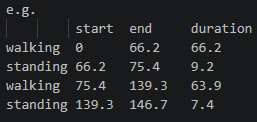

so that 9.2 standing gap is best chance.... so if our recording for IMU started close to when vid did then that standing dip part should come close to the 60-90 sec mark.... so let's zoom in on that:

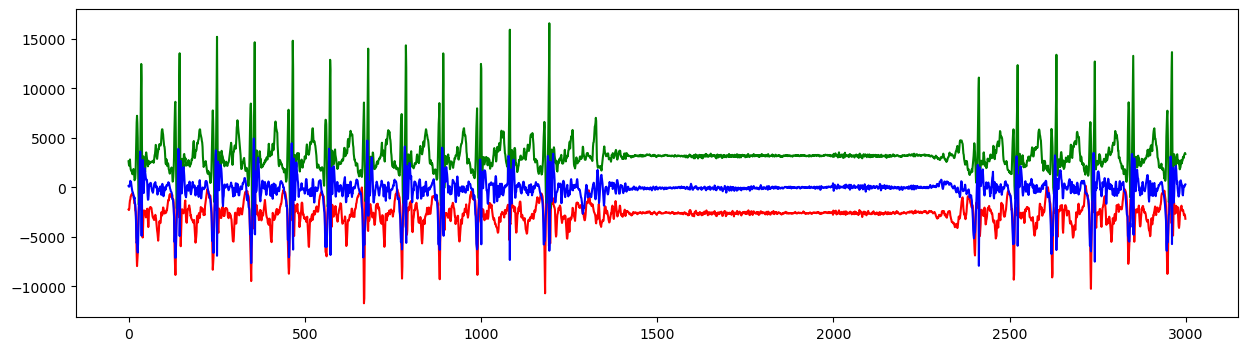

In [15]:
focused_section_start = 6000 # as 60 sec = 60*100 samples
focused_section_end = 9000 # same story, 90 sec = 90 * 100

fig,ax = plt.subplots(figsize=(15,4))
ax.plot(x_axis_acceleration_data[focused_section_start:focused_section_end], color='r')
ax.plot(y_axis_acceleration_data[focused_section_start:focused_section_end], color='g')
ax.plot(z_axis_acceleration_data[focused_section_start:focused_section_end], color='b')

inshallah...hehehe SIUUUU

so it seems like ~1350-1400 sample mark should be when the standing part starts, i.e. at 66.2 sec in the video.... so now we can work backwards. Look @ it it's perfect.. it lasts around like 920-950 samples as we'd expect...

so the standing start index is like 1400 + 6000 = 7400:

In [40]:
standing_start_index = 7300

standing_start_timestamp = time_track[standing_start_index]
print(standing_start_timestamp)

1598240287.0


So this ^ is the timestamp from the csv which the standing begings i.e. at 66.2 sec

In [41]:
video_start_timestamp = standing_start_timestamp - 66.2
# puta madre, our time_track is storing whole secs never fractions.... & throwing fractions gives
# e.g. Value Error: 1598240221.8 is not in list... so let's just round best we can do:
# ahh u know what instead of doing this all the time:
# video_start_index = time_track.index(int(round(video_start_timestamp)))
# let's create a function for it... kills two birs w one stone, saves time + rubrics reusable functions..

def find_index_for_timestamp(curr_timestamp:float,time_track:list[float])-> int:
    '''
        TODO: Docstring
    '''
    return time_track.index(int(round(curr_timestamp)))

video_start_index = find_index_for_timestamp(video_start_timestamp,time_track)

print("Video starts @ timestamp: %s" %video_start_timestamp)
print("Video start index (si senor, w/ some rounding): %s " %video_start_index)

Video starts @ timestamp: 1598240220.8
Video start index (si senor, w/ some rounding): 800 


we know our vid is 711 sec.... so the end calculation should be easy:
- end_index = time_track.index(video_start_timestamp+711)

but let's just double check with one more set of points & our start index to make sure we are accurate:

Let's run it on the standing gap between 139.333 & 146.7333 & using our ```video_start_timestamp```:


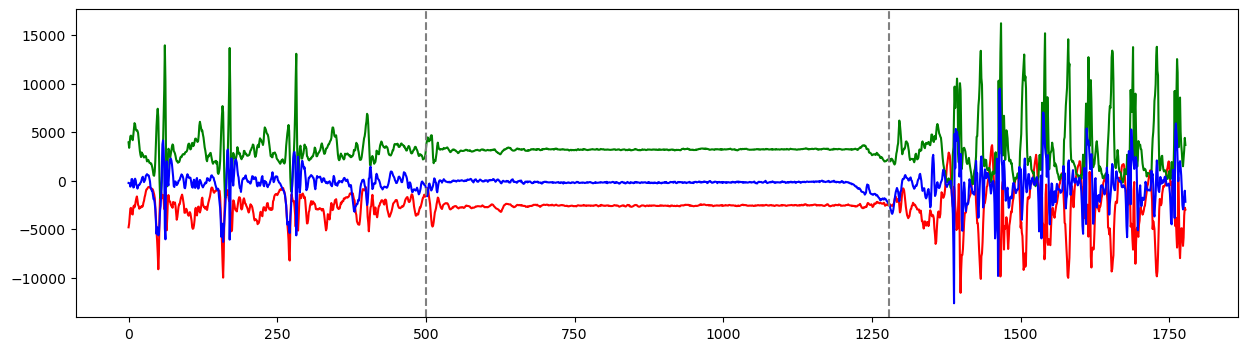

In [42]:
focused_section2_start = find_index_for_timestamp(video_start_timestamp + 139.333,time_track) 
focused_section2_end = find_index_for_timestamp(video_start_timestamp + 146.733,time_track)
window_len = focused_section2_end - focused_section2_start

pad=500
fig,ax = plt.subplots(figsize=(15,4))
ax.plot(x_axis_acceleration_data[focused_section2_start-pad:focused_section2_end+pad], color='r')
ax.plot(y_axis_acceleration_data[focused_section2_start-pad:focused_section2_end+pad], color='g')
ax.plot(z_axis_acceleration_data[focused_section2_start-pad:focused_section2_end+pad], color='b')
ax.axvline(pad, color='gray', linestyle='--') # marks where window thinks it starts
ax.axvline(pad + (focused_section2_end-focused_section2_start), color='gray', linestyle='--') # marks where window thinks it ends

index 7300 from above performs better than 7400... so i think i'll settle w/7300...